# Análise de Dados de Filmes

Este notebook contém várias análises sobre dados de filmes, explorando diferentes aspectos como orçamento, receita, equipe, gêneros e muito mais.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Carregando o dataset
script_dir = os.path.dirname(os.path.abspath('__file__'))
DATASET_PATH = os.path.join(script_dir, 'movies.csv')

try:
    df = pd.read_csv(DATASET_PATH)
    print("Dataset carregado com sucesso!")
    print(f"Número de filmes: {len(df)}")
    print("\nPrimeiras linhas do dataset:")
    display(df.head())
except FileNotFoundError:
    print("Erro: Arquivo movies.csv não encontrado")

Dataset carregado com sucesso!
Número de filmes: 4803

Primeiras linhas do dataset:


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


## 1. Análise de Orçamento e Receita

Vamos analisar a relação entre o orçamento dos filmes e sua receita, calculando também o ROI (Return on Investment).

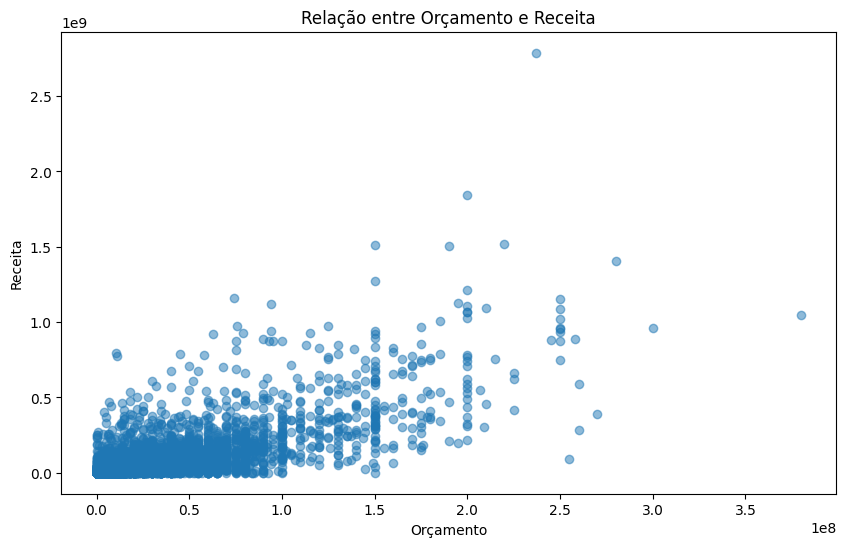

Correlação entre orçamento e receita: 0.73

Estatísticas do ROI:
count    3913.000000
mean             inf
std              NaN
min        -1.000000
25%        -0.454545
50%         0.999014
75%         3.326712
max              inf
Name: ROI, dtype: float64


c:\Users\julio\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [2]:
def analise_orcamento_receita(df):
    # Calculando o ROI
    df['ROI'] = (df['revenue'] - df['budget']) / df['budget']

    # Criando o gráfico de dispersão
    plt.figure(figsize=(10, 6))
    plt.scatter(df['budget'], df['revenue'], alpha=0.5)
    plt.xlabel('Orçamento')
    plt.ylabel('Receita')
    plt.title('Relação entre Orçamento e Receita')
    plt.show()

    # Calculando a correlação
    correlacao = df['budget'].corr(df['revenue'])
    print(f"Correlação entre orçamento e receita: {correlacao:.2f}")
    
    # Exibindo estatísticas do ROI
    print(f"\nEstatísticas do ROI:")
    print(df['ROI'].describe())

analise_orcamento_receita(df)

## 2. Análise de Produtoras

Vamos investigar como o número de produtoras envolvidas se correlaciona com o orçamento e a bilheteria dos filmes.

Análise de produtoras em desenvolvimento...


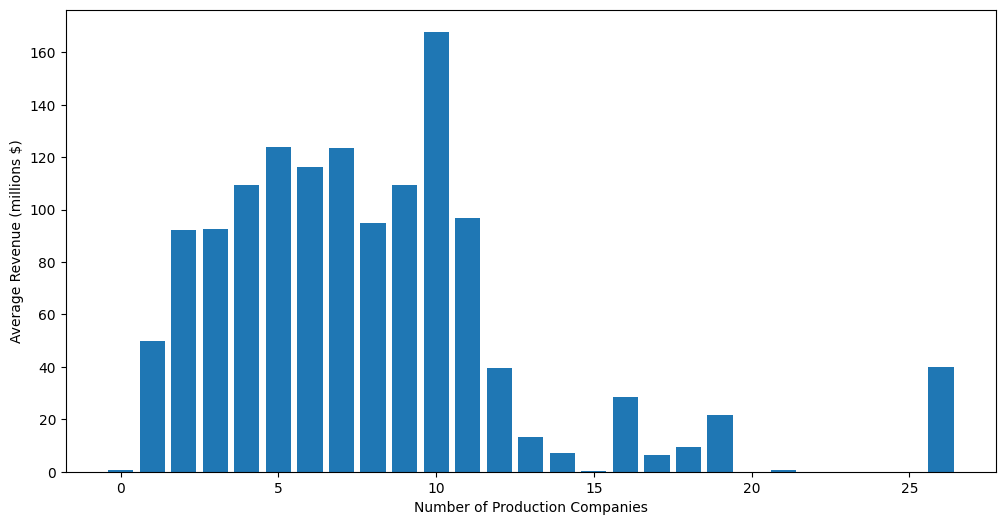

In [3]:
def analise_produtoras(df):
    print("Análise de produtoras em desenvolvimento...")# Create a column with the count of production companies
    df['production_company_count'] = df['production_companies'].apply(lambda x: len(eval(x)))

    # Group by company count and analyze
    company_analysis = df.groupby('production_company_count').agg({
        'budget': 'mean',
        'revenue': 'mean',
        'vote_average': 'mean'
    }).reset_index()

    # Visualize the results
    plt.figure(figsize=(12, 6))
    plt.bar(company_analysis['production_company_count'], company_analysis['revenue'] / 1000000)
    plt.xlabel('Number of Production Companies')
    plt.ylabel('Average Revenue (millions $)')
    # Implementação futura

analise_produtoras(df)

## 3. Análise de Atores

Vamos identificar quais atores aparecem mais de uma vez nos filmes mais bem avaliados (média de avaliação maior que 8.5)

Actors who appeared more than once in highly rated movies:
cast_list
Robert De        3
Tom Hanks        2
Edward Norton    2
Martin Balsam    2
Al Pacino        2
Name: count, dtype: int64


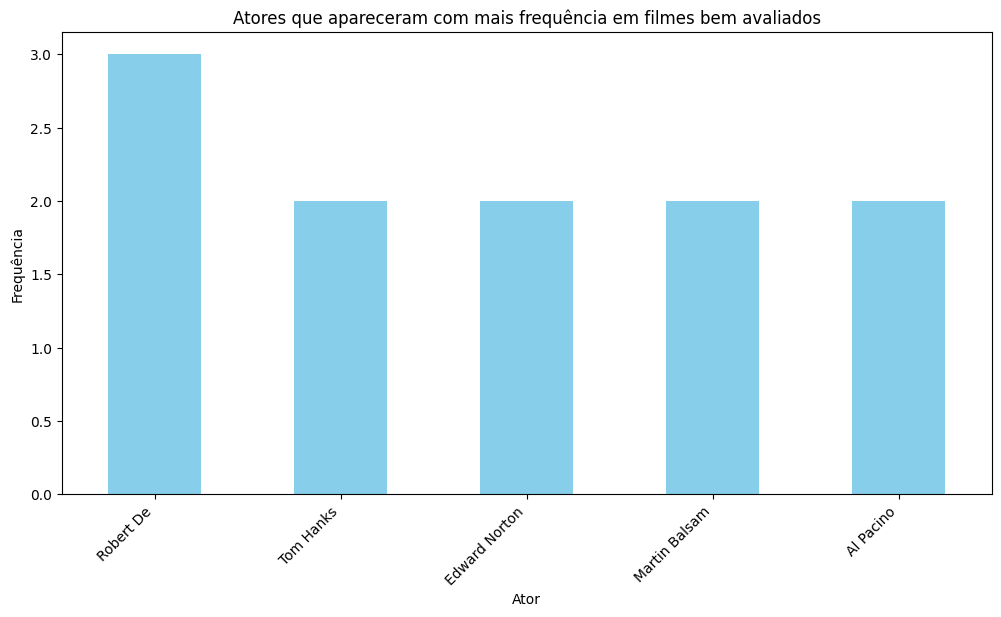

In [18]:
def analise_diretores_atores(df):
    # Convert vote_average to numeric
    df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')

    # Filter movies with high ratings
    well_evaluated_threshold = 8.2
    high_rated_df = df[df['vote_average'] >= well_evaluated_threshold].copy()

    # Ensure cast is string
    high_rated_df['cast'] = high_rated_df['cast'].astype(str)

    # Function to split cast string into actor names (assuming each actor has 2 words)
    def split_cast(cast_str):
        tokens = cast_str.strip().split()
        return [' '.join(tokens[i:i+2]) for i in range(0, len(tokens), 2) if i+1 < len(tokens)]

    # Apply split and explode
    high_rated_df['cast_list'] = high_rated_df['cast'].apply(split_cast)
    exploded_cast = high_rated_df.explode('cast_list')

    # Count actor appearances
    actor_counts = exploded_cast['cast_list'].value_counts()
    popular_actors = actor_counts[actor_counts > 1]

    # Output result
    print("Actors who appeared more than once in highly rated movies:")
    print(popular_actors)

    # Plot
    plt.figure(figsize=(12, 6))
    popular_actors.plot(kind='bar', color='skyblue')
    plt.title('Atores que apareceram com mais frequência em filmes bem avaliados')
    plt.xlabel('Ator')
    plt.ylabel('Frequência')
    plt.xticks(rotation=45, ha='right')
    plt.show()
    
analise_diretores_atores(df)


## 4. Análise de Duração e Popularidade

Vamos investigar se existe alguma relação entre a duração do filme e sua popularidade ou avaliação.

Análise de duração e popularidade em desenvolvimento...
Runtime-Popularity correlation: 0.23
Runtime-Vote Average correlation: 0.38


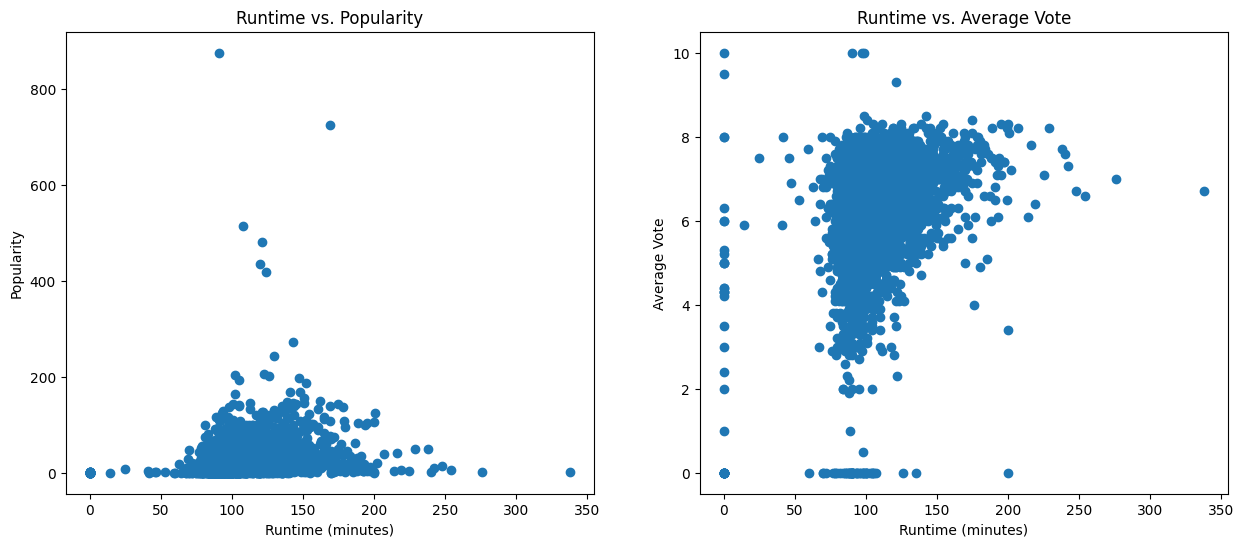

In [4]:
def analise_duracao_popularidade(df):
    print("Análise de duração e popularidade em desenvolvimento...")
    # Create scatter plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.scatter(df['runtime'], df['popularity'])
    ax1.set_title('Runtime vs. Popularity')
    ax1.set_xlabel('Runtime (minutes)')
    ax1.set_ylabel('Popularity')

    ax2.scatter(df['runtime'], df['vote_average'])
    ax2.set_title('Runtime vs. Average Vote')
    ax2.set_xlabel('Runtime (minutes)')
    ax2.set_ylabel('Average Vote')

    # Calculate correlations
    runtime_popularity_corr = df['runtime'].corr(df['popularity'])
    runtime_vote_corr = df['runtime'].corr(df['vote_average'])
    print(f"Runtime-Popularity correlation: {runtime_popularity_corr:.2f}")
    print(f"Runtime-Vote Average correlation: {runtime_vote_corr:.2f}") 

analise_duracao_popularidade(df)

## 5. Análise de Diversidade de Gênero

Vamos analisar a diversidade de gênero nas equipes de produção dos filmes.

Análise de diversidade de gênero em desenvolvimento...


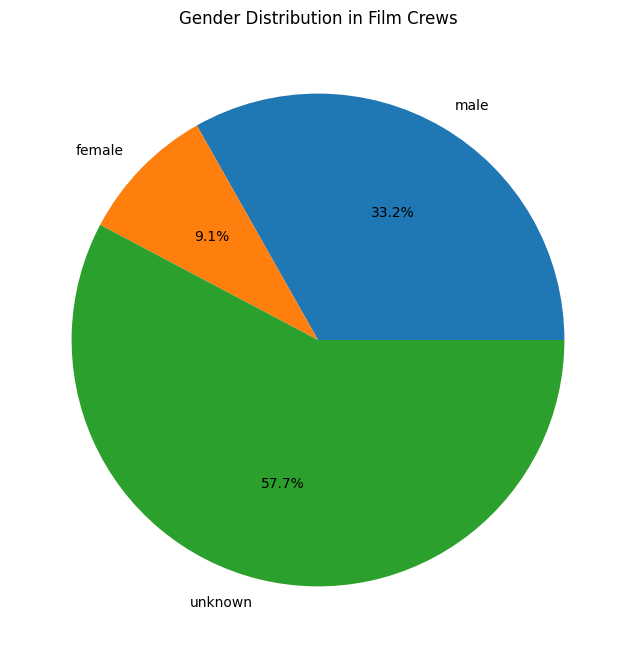

In [5]:
def analise_diversidade_genero(df):
    print("Análise de diversidade de gênero em desenvolvimento...")
    def extract_gender_data(crew_str):
        crew = eval(crew_str)
        gender_counts = {'male': 0, 'female': 0, 'unknown': 0}
        
        for person in crew:
            if person['gender'] == 1:
                gender_counts['female'] += 1
            elif person['gender'] == 2:
                gender_counts['male'] += 1
            else:
                gender_counts['unknown'] += 1
        
        return pd.Series(gender_counts)

    gender_df = df['crew'].apply(extract_gender_data)
    gender_totals = gender_df.sum()

    # Create pie chart
    plt.figure(figsize=(8, 8))
    plt.pie(gender_totals, labels=gender_totals.index, autopct='%1.1f%%')
    plt.title('Gender Distribution in Film Crews')

analise_diversidade_genero(df)

## 6. Análise de Gêneros e Orçamento

Vamos investigar quais gêneros têm maiores orçamentos e se isso resulta em maior receita.

Análise de gêneros e orçamento em desenvolvimento...


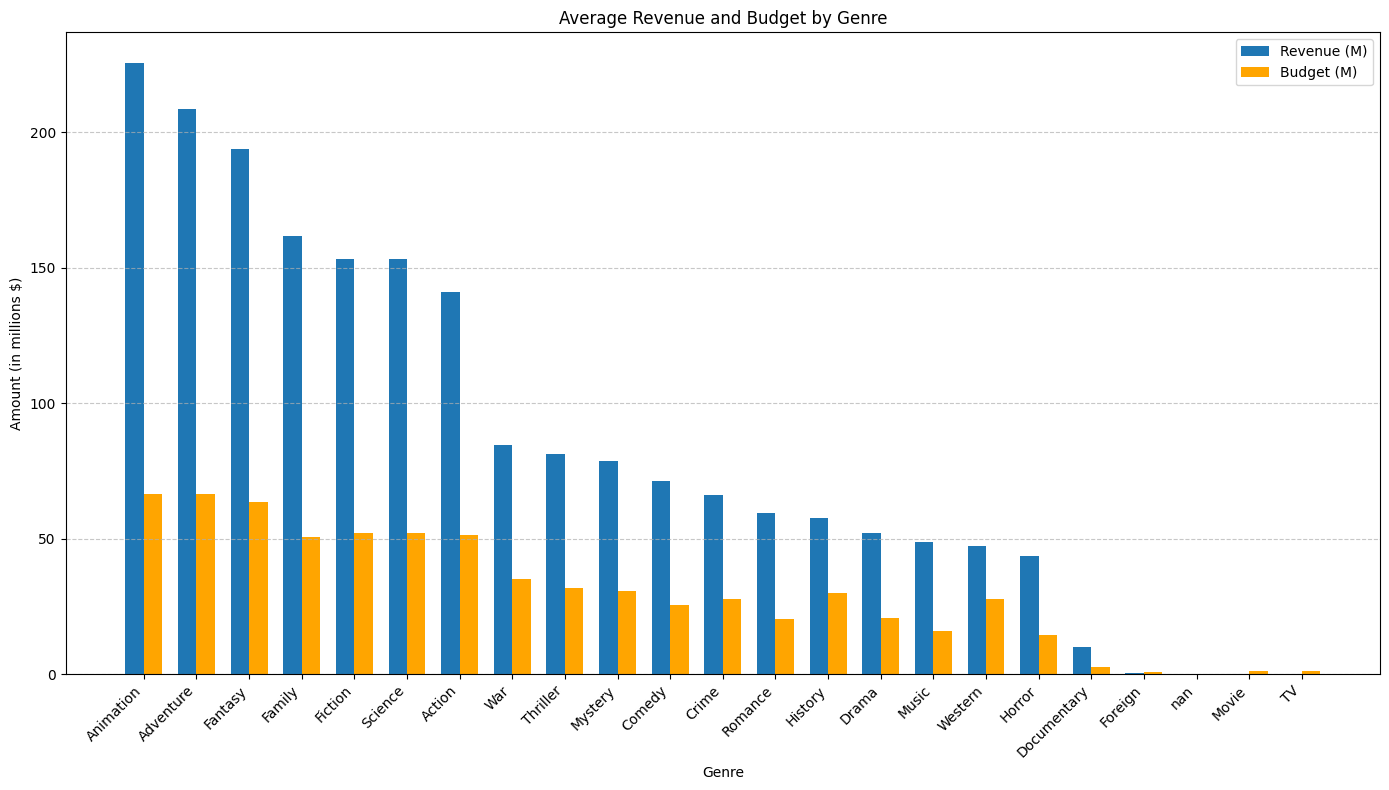

In [ ]:
def analise_generos_orcamento(df):
    # Extract genres and create genre combinations
    df['genre_list'] = df['genres'].astype(str).str.split()

    # Explode the dataframe so each genre gets its own row
    exploded_df = df.explode('genre_list')

    # Group by genre and calculate mean budget, revenue, vote_average, and count
    genre_analysis = exploded_df.groupby('genre_list').agg({
        'budget': 'mean',
        'revenue': 'mean',
        'vote_average': 'mean',
        'index': 'count'
    }).rename(columns={'index': 'count'}).reset_index()

    # Sort by revenue
    genre_analysis = genre_analysis.sort_values('revenue', ascending=False)

    # Plot side-by-side bar charts for budget and revenue
    genres = genre_analysis['genre_list']
    x = np.arange(len(genres))  # label locations
    width = 0.35  # bar width

    fig, ax = plt.subplots(figsize=(14, 8))
    revenue_bars = ax.bar(x - width/2, genre_analysis['revenue'] / 1e6, width, label='Revenue (M)')
    budget_bars = ax.bar(x + width/2, genre_analysis['budget'] / 1e6, width, label='Budget (M)', color='orange')

    ax.set_xlabel('Genre')
    ax.set_ylabel('Amount (in millions $)')
    ax.set_title('Average Revenue and Budget by Genre')
    ax.set_xticks(x)
    ax.set_xticklabels(genres, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Call the function
analise_generos_orcamento(df)

## 7. Análise de Tamanho da Equipe

Vamos analisar como o tamanho da equipe se relaciona com o orçamento e o sucesso dos filmes.

Análise de equipe e orçamento em desenvolvimento...
Correlation between crew size and revenue: 0.42


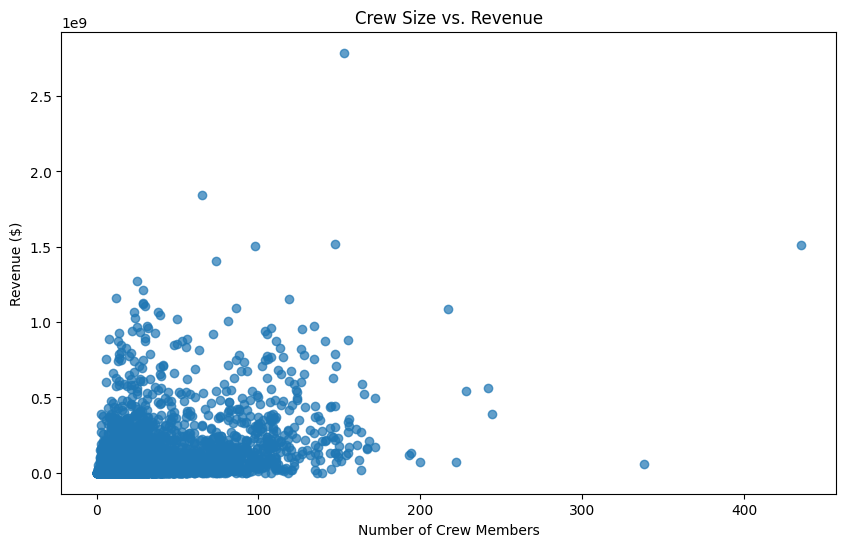

In [ ]:
def analise_equipe_orcamento(df):
    # Calculate crew size
    df['crew_size'] = df['crew'].apply(lambda x: len(eval(x)))

    # Create scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(df['crew_size'], df['revenue'], alpha=0.7)
    plt.title('Crew Size vs. Revenue')
    plt.xlabel('Number of Crew Members')
    plt.ylabel('Revenue ($)')

    # Calculate correlation
    crew_revenue_corr = df['crew_size'].corr(df['revenue'])
    print(f"Correlation between crew size and revenue: {crew_revenue_corr:.2f}")
analise_equipe_orcamento(df)

## 8. Análise dos filmes em relação aos diretores

Vamos analisar quais foram os diretores com mais filmes lançados e sua média de avaliação

Director who launched the most movies:
                  movie_count  average_rating
director                                     
Steven Spielberg           27        6.974074


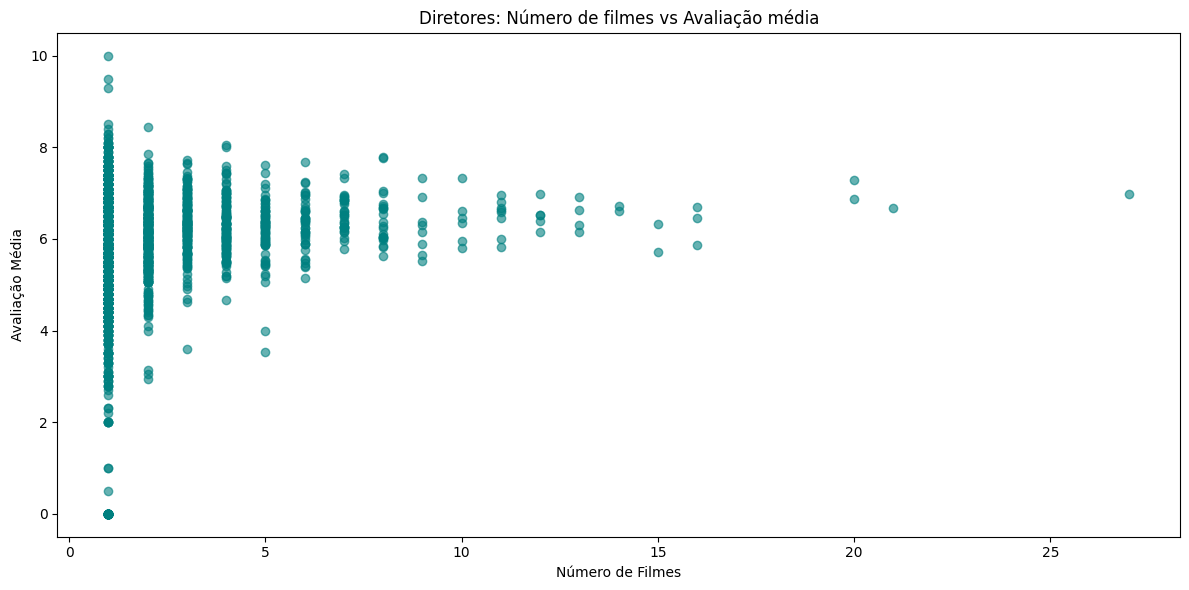

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def analise_filmes_diretores(df):
    # Ensure vote_average is numeric
    df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')

    # Remove rows without a director
    df = df[df['director'].notna()]

    # Group by director
    director_stats = df.groupby('director').agg(
        movie_count=('title', 'count'),
        average_rating=('vote_average', 'mean')
    )

    # Find the director with most movies
    top_director = director_stats.sort_values(by='movie_count', ascending=False).head(1)

    print("Diretor com mais filmes:")
    print(top_director)

    # Plot movie_count vs average_rating
    plt.figure(figsize=(12, 6))
    plt.scatter(director_stats['movie_count'], director_stats['average_rating'], alpha=0.6, color='teal')
    plt.title('Diretores: Número de filmes vs Avaliação média')
    plt.xlabel('Número de Filmes')
    plt.ylabel('Avaliação Média')
    plt.tight_layout()
    plt.show()

analise_filmes_diretores(df)


## 9. Análise de Data de Lançamento

Vamos investigar se existe correlação entre a data de lançamento e o desempenho de bilheteria.

Análise de data de lançamento em desenvolvimento...


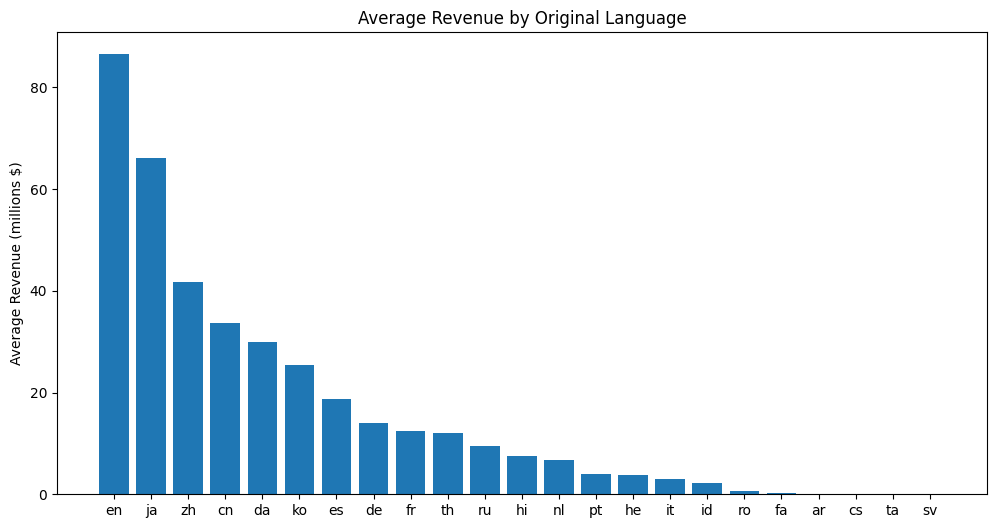

In [ ]:
def analise_data_bilheteria(df):
    print("Análise de data de lançamento em desenvolvimento...")
    language_analysis = df.groupby('original_language').agg({
        'index': 'count',
        'budget': 'mean',
        'revenue': 'mean',
        'vote_average': 'mean'
    }).rename(columns={'index': 'movie_count'}).reset_index()

    # Filter languages with at least 2 movies
    language_analysis = language_analysis[language_analysis['movie_count'] >= 2]

    # Sort by average revenue
    language_analysis = language_analysis.sort_values('revenue', ascending=False)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.bar(language_analysis['original_language'], language_analysis['revenue'] / 1000000)
    plt.ylabel('Average Revenue (millions $)')
    plt.title('Average Revenue by Original Language')
analise_data_bilheteria(df)

## Análise do rendimento em relação ao mês de lançamento.

Vamos analisar como o mês de lançamento do filme influencia em seu rendimento

Análise temporal de orçamento e receita em desenvolvimento...


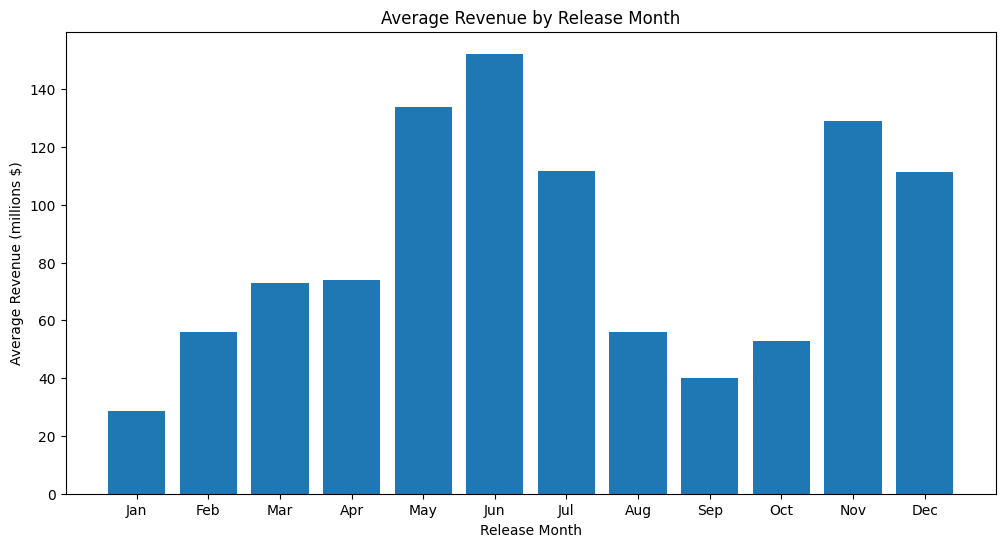

In [ ]:
def analise_orcamento_tempo(df):
    df['release_month'] = pd.to_datetime(df['release_date']).dt.month

    monthly_performance = df.groupby('release_month').agg({
        'revenue': 'mean',
        'index': 'count'
    }).rename(columns={'index': 'movie_count'}).reset_index()

    plt.figure(figsize=(12, 6))
    plt.bar(monthly_performance['release_month'], monthly_performance['revenue'] / 1000000)
    plt.xlabel('Release Month')
    plt.ylabel('Average Revenue (millions $)')
    plt.title('Average Revenue by Release Month')
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
analise_orcamento_tempo(df)